<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask:
      linear-gradient(#fff 0 0) content-box,
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>02 $\rightarrow$ Image Classification with CNN using Keras</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">Training a CNN in Keras with TensorFlow Backend for Multi-Class Image Classification (CIFAR-10)</span>
</div>

---

# Table of Contents

1. [Import Libraries & Hardware Setup](#1-import-libraries--hardware-setup)
2. [Preprocess Data & Exploratory Analysis](#2-preprocess-data--exploratory-analysis)
   - 2.1 [Class Selection & Filtering](#21-class-selection--filtering)
   - 2.2 [Load Dataset, Normalization & Shape Verification](#22-load-dataset-normalization--shape-verification)
   - 2.3 [Class Distribution Analysis](#23-class-distribution-analysis)
   - 2.4 [RGB Color Channel Intensity Distribution](#24-rgb-color-channel-intensity-distribution)
3. [Visualize Dataset Examples](#3-visualize-dataset-examples)
   - 3.1 [Display Training Examples](#31-display-training-examples)
   - 3.2 [Display Test Examples](#32-display-test-examples)
4. [Create CNN Architecture](#4-create-cnn-architecture)
   - 4.1 [CNN Architecture & Model Compilation](#41-cnn-architecture--model-compilation)
5. [Train the Model & Learning Diagnostics](#5-train-the-model--learning-diagnostics)
   - 5.1 [Fit Model with Modern Callbacks](#51-fit-model-with-modern-callbacks)
   - 5.2 [Learning Curves: Accuracy & Loss Dynamics](#52-learning-curves-accuracy--loss-dynamics)
   - 5.3 [Model Checkpointing in Keras](#53-model-checkpointing-in-keras)
6. [Evaluation, Performance Metrics & Interpretability](#6-evaluation-performance-metrics--interpretability)
   - 6.1 [Load Best Model Checkpoint](#61-load-best-model-checkpoint)
   - 6.2 [Normalized Confusion Matrix Heatmap](#62-normalized-confusion-matrix-heatmap)
   - 6.3 [Per-Class Classification Metrics (Precision, Recall, F1)](#63-per-class-classification-metrics-precision-recall-f1)
   - 6.4 [Prediction Confidence & Softmax Probability Distributions](#64-prediction-confidence--softmax-probability-distributions)
   - 6.5 [Feature Map / Layer Activation Visualization](#65-feature-map--layer-activation-visualization)
   - 6.6 [Final Test Predictions Display](#66-final-test-predictions-display)

---

<a id="1-import-libraries--hardware-setup"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Import Libraries & Hardware Setup</span>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

In [2]:
# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# Create directory for saving model checkpoints
os.makedirs('models', exist_ok=True)

In [ ]:
# Hardware and environment verification (using non-deprecated APIs)
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {keras.__version__}")

TensorFlow Version: 2.20.0
Keras Version:      3.13.2


In [4]:
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU Available:      {bool(gpus)}")

if gpus:
    for gpu in gpus:
        print(f"  - Device: {gpu.name}")
else:
    print("  - Running on CPU mode")

GPU Available:      True
  - Device: /physical_device:GPU:0


<a id="2-preprocess-data--exploratory-analysis"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Preprocess Data & Exploratory Analysis</span>

<a id="21-class-selection--filtering"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.1 Class Selection & Filtering</span>

In [5]:
def get_three_classes(x, y):
    """
    Filters dataset to retain only classes:
      0: Aeroplane
      1: Automobile (Car)
      2: Bird
    Applies one-hot encoding to targets and shuffles the subset randomly.
    """
    # Vectorized indexing for classes 0, 1, and 2
    indices = np.where(np.isin(y.flatten(), [0, 1, 2]))[0]

    x = x[indices]
    y = y[indices]

    # Shuffle subset
    perm = np.random.permutation(len(x))
    x = x[perm]
    y = y[perm]

    # One-hot encode targets for 3 classes
    y = keras.utils.to_categorical(y, num_classes=3)

    return x, y

<a id="22-load-dataset-normalization--shape-verification"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.2 Load Dataset, Normalization & Shape Verification</span>

In [6]:
# Loading CIFAR-10 dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

# Extract 3-class subsets for training and testing
x_train, y_train = get_three_classes(x_train_raw, y_train_raw)
x_test, y_test = get_three_classes(x_test_raw, y_test_raw)

# Standardize pixel values to [0.0, 1.0]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Training Data Shape:   Images {x_train.shape} | Labels {y_train.shape}")
print(f"Testing Data Shape:    Images {x_test.shape}  | Labels {y_test.shape}")
print(f"Pixel Range (Min-Max): [{x_train.min():.1f}, {x_train.max():.1f}]")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 585s 3us/step
Training Data Shape:   Images (15000, 32, 32, 3) | Labels (15000, 3)
Testing Data Shape:    Images (3000, 32, 32, 3)  | Labels (3000, 3)
Pixel Range (Min-Max): [0.0, 1.0]


<a id="23-class-distribution-analysis"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.3 Class Distribution Analysis</span>

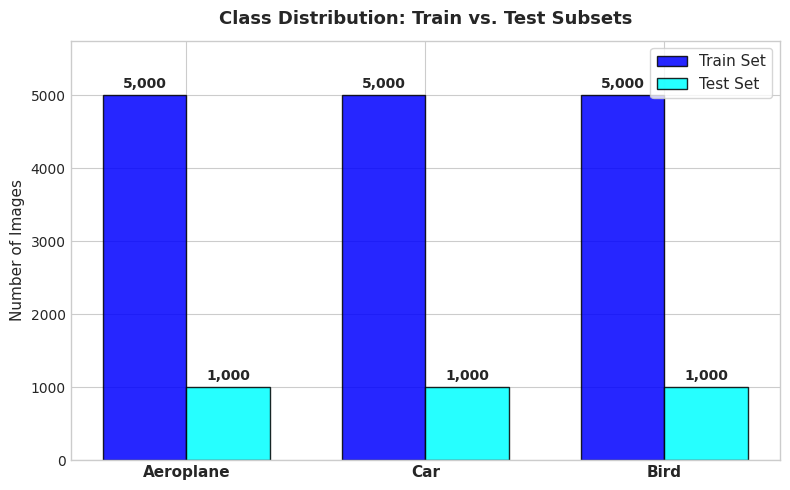

In [7]:
class_names = ['aeroplane', 'car', 'bird']

# Calculate distribution counts for Train and Test sets
train_counts = [np.sum(np.argmax(y_train, axis=1) == i) for i in range(3)]
test_counts = [np.sum(np.argmax(y_test, axis=1) == i) for i in range(3)]

x_pos = np.arange(len(class_names))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_train = ax.bar(x_pos - bar_width/2, train_counts, bar_width, label='Train Set', color='blue', edgecolor='black', alpha=0.85)
bars_test = ax.bar(x_pos + bar_width/2, test_counts, bar_width, label='Test Set', color='cyan', edgecolor='black', alpha=0.85)

# Add value labels above bars
for bar in bars_train:
    h = bar.get_height()
    ax.annotate(f'{h:,}', xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=10)
for bar in bars_test:
    h = bar.get_height()
    ax.annotate(f'{h:,}', xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Class Distribution: Train vs. Test Subsets', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_xticks(x_pos)
ax.set_xticklabels([c.title() for c in class_names], fontsize=11, fontweight='bold')
ax.legend(frameon=True, fontsize=11)
ax.set_ylim(0, max(train_counts) * 1.15)

plt.tight_layout()
plt.show()

<a id="24-rgb-color-channel-intensity-distribution"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.4 RGB Color Channel Intensity Distribution</span>

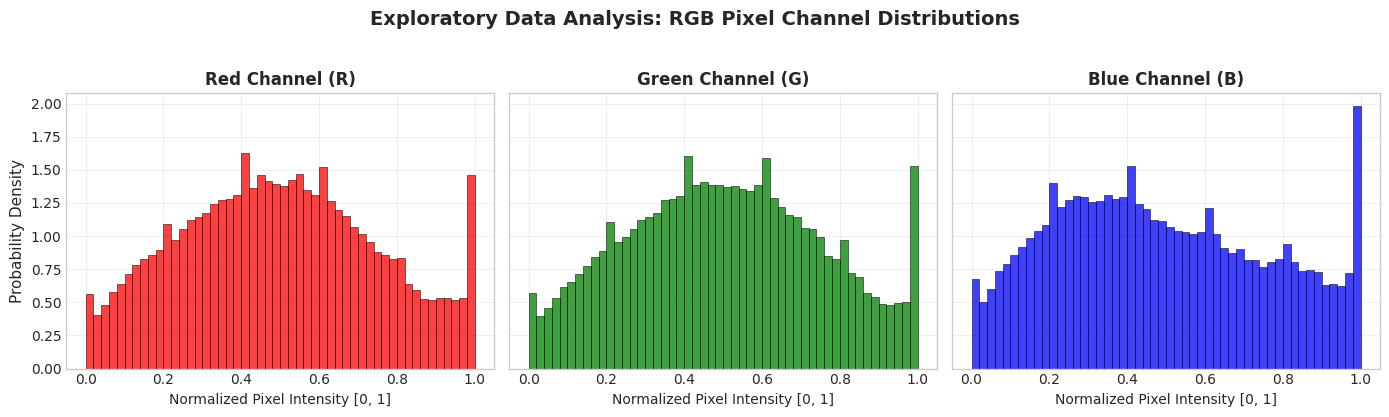

In [8]:
# Sample 1,000 images to inspect normalized channel distributions
sample_images = x_train[np.random.choice(len(x_train), size=min(1000, len(x_train)), replace=False)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
channel_configs = [
    (0, 'red', 'Red Channel (R)'),
    (1, 'green', 'Green Channel (G)'),
    (2, 'blue', 'Blue Channel (B)')
]

for idx, color, title in channel_configs:
    vals = sample_images[:, :, :, idx].flatten()
    axes[idx].hist(vals, bins=50, color=color, alpha=0.75, edgecolor='black', linewidth=0.5, density=True)
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Normalized Pixel Intensity [0, 1]', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

axes[0].set_ylabel('Probability Density', fontsize=11)
plt.suptitle('Exploratory Data Analysis: RGB Pixel Channel Distributions', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

<a id="3-visualize-dataset-examples"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Visualize Dataset Examples</span>

<a id="31-display-training-examples"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.1 Display Training Examples</span>

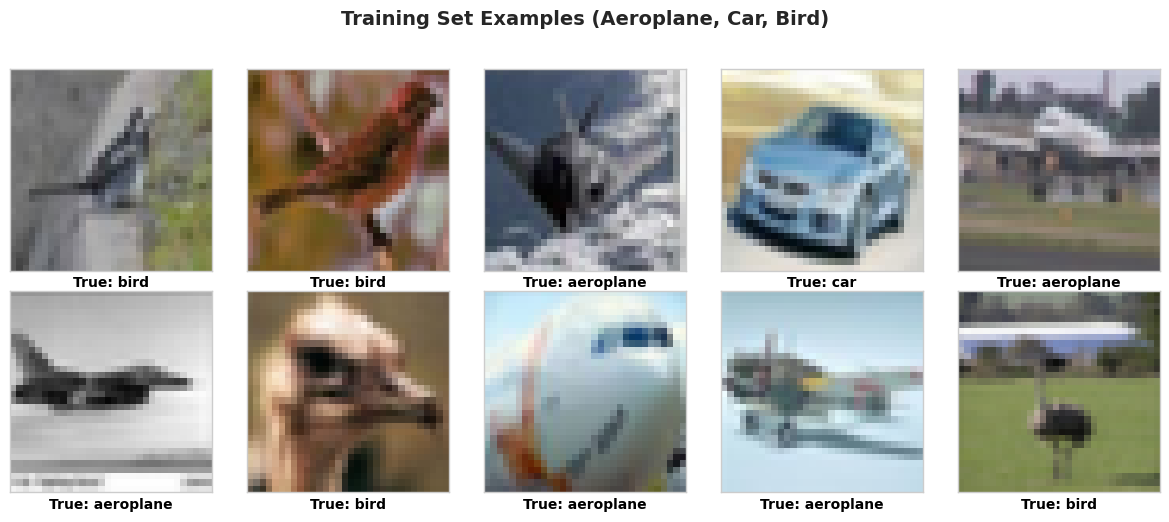

In [9]:
def show_random_examples(x, y, p=None, title="Random Sample Visualizations"):
    """
    Displays a 2x5 grid of random dataset images with ground truth and predicted labels.
    """
    indices = np.random.choice(range(x.shape[0]), 10, replace=False)

    plt.figure(figsize=(12, 5))
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, 1 + i)
        plt.imshow(x[idx])
        plt.xticks([])
        plt.yticks([])

        true_label = class_names[np.argmax(y[idx])]
        if p is not None:
            pred_label = class_names[np.argmax(p[idx])]
            is_correct = (np.argmax(y[idx]) == np.argmax(p[idx]))
            col = 'green' if is_correct else 'red'
            plt.xlabel(f"Pred: {pred_label}\nTrue: {true_label}", color=col, fontsize=10, fontweight='bold')
        else:
            plt.xlabel(f"True: {true_label}", color='black', fontsize=10, fontweight='bold')

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Visualize 10 random training examples
show_random_examples(x_train, y_train, title="Training Set Examples (Aeroplane, Car, Bird)")

<a id="32-display-test-examples"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.2 Display Test Examples</span>

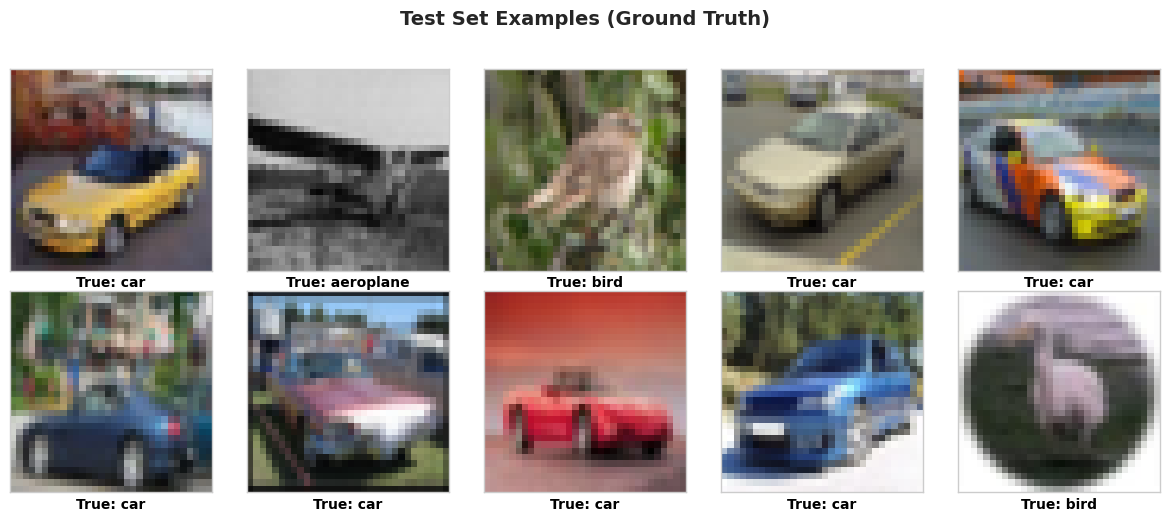

In [10]:
# Visualize 10 random test set examples
show_random_examples(x_test, y_test, title="Test Set Examples (Ground Truth)")

<a id="4-create-cnn-architecture"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Create CNN Architecture</span>

<a id="41-cnn-architecture--model-compilation"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.1 CNN Architecture & Model Compilation</span>

In [11]:
def create_model():
    """
    Builds a deep Convolutional Neural Network with 3 convolutional blocks:
    - Conv2D (with padding='same') + BatchNormalization
    - Conv2D + MaxPooling2D + Spatial Dropout
    - Dense Softmax output for 3 classes
    """
    def add_conv_block(model, num_filters):
        model.add(layers.Conv2D(num_filters, (3, 3), activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(num_filters, (3, 3), activation='relu'))
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))
        model.add(layers.Dropout(0.5))
        return model

    model = models.Sequential([
        layers.Input(shape=(32, 32, 3))
    ])

    # 3 Progressive Feature Extraction Stages
    model = add_conv_block(model, 32)
    model = add_conv_block(model, 64)
    model = add_conv_block(model, 128)

    # Classification Head
    model.add(layers.Flatten())
    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )

    return model

model = create_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,443 (1.10 MB)

 Trainable params: 288,995 (1.10 MB)

 Non-trainable params: 448 (1.75 KB)

<a id="5-train-the-model--learning-diagnostics"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Train the Model & Learning Diagnostics</span>

<a id="51-fit-model-with-modern-callbacks"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.1 Fit Model with Modern Callbacks</span>

In [12]:
# Configure robust checkpointing and early stopping callbacks
checkpoint_dir = 'models'
os.makedirs(checkpoint_dir, exist_ok=True)
best_checkpoint_path = os.path.join(checkpoint_dir, 'model_best.keras')

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=best_checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the model with test-set validation (fixing previous bug where validation used training data)
h = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5961 - loss: 1.2105
Epoch 1: val_accuracy improved from None to 0.33333, saving model to models/model_best.keras

Epoch 1: finished saving model to models/model_best.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.6749 - loss: 0.9039 - val_accuracy: 0.3333 - val_loss: 2.7983
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7711 - loss: 0.5692
Epoch 2: val_accuracy improved from 0.33333 to 0.33367, saving model to models/model_best.keras

Epoch 2: finished saving model to models/model_best.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7803 - loss: 0.5481 - val_accuracy: 0.3337 - val_loss: 2.8857
Epoch 3/10
113/118 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7956 - loss: 0.5056
Epoch 3: val_accuracy improved from 0.33367 to 0.46667, saving model to models/model_best.keras

Epoch 3: finished saving model to models/model_best.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/ste

<a id="52-learning-curves-accuracy--loss-dynamics"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.2 Learning Curves: Accuracy & Loss Dynamics</span>

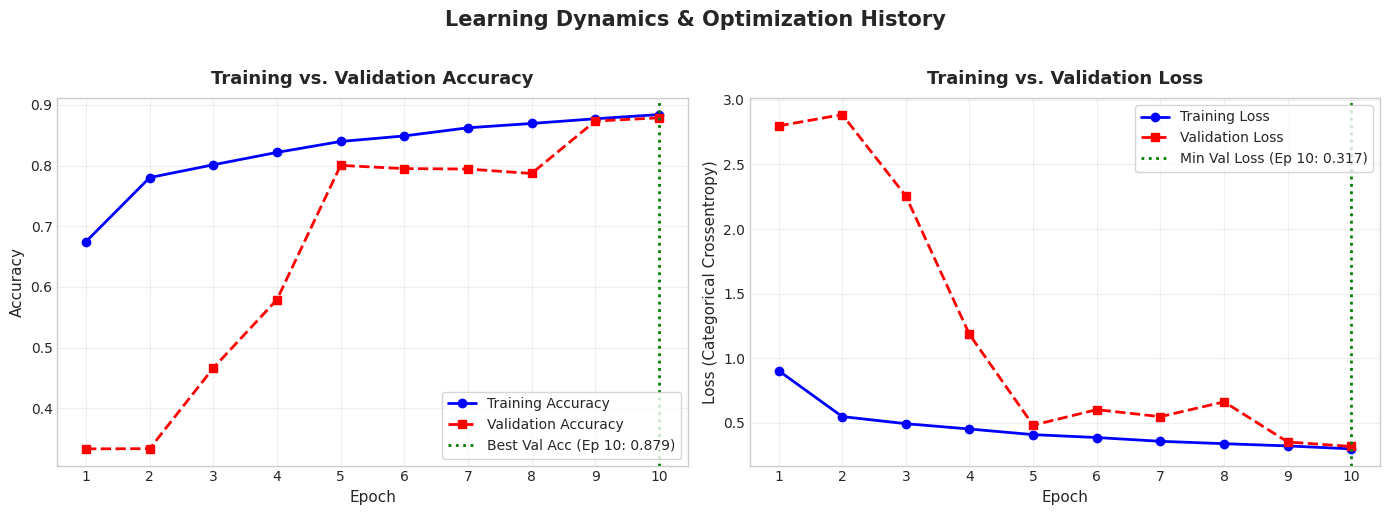

In [13]:
accs = h.history['accuracy']
val_accs = h.history['val_accuracy']
losses = h.history['loss']
val_losses = h.history['val_loss']
epochs_range = range(1, len(accs) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy Curve ---
ax1.plot(epochs_range, accs, 'o-', label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(epochs_range, val_accs, 's--', label='Validation Accuracy', color='red', linewidth=2)
best_acc_epoch = int(np.argmax(val_accs)) + 1
ax1.axvline(best_acc_epoch, color='green', linestyle=':', linewidth=2, label=f'Best Val Acc (Ep {best_acc_epoch}: {val_accs[best_acc_epoch-1]:.3f})')
ax1.set_title('Training vs. Validation Accuracy', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_xticks(list(epochs_range))
ax1.legend(loc='lower right', frameon=True)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Loss Curve ---
ax2.plot(epochs_range, losses, 'o-', label='Training Loss', color='blue', linewidth=2)
ax2.plot(epochs_range, val_losses, 's--', label='Validation Loss', color='red', linewidth=2)
min_loss_epoch = int(np.argmin(val_losses)) + 1
ax2.axvline(min_loss_epoch, color='green', linestyle=':', linewidth=2, label=f'Min Val Loss (Ep {min_loss_epoch}: {val_losses[min_loss_epoch-1]:.3f})')
ax2.set_title('Training vs. Validation Loss', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss (Categorical Crossentropy)', fontsize=11)
ax2.set_xticks(list(epochs_range))
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, alpha=0.3)

plt.suptitle('Learning Dynamics & Optimization History', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id="53-model-checkpointing-in-keras"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.3 Model Checkpointing in Keras</span>

> **Resource References:**
> - [tf.keras.callbacks.ModelCheckpoint Documentation](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint)
> - [How to Checkpoint Deep Learning Models in Keras (Machine Learning Mastery)](https://machinelearningmastery.com/check-point-deep-learning-models-keras/)

<a id="6-evaluation-performance-metrics--interpretability"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Evaluation, Performance Metrics & Interpretability</span>

<a id="61-load-best-model-checkpoint"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Load Best Model Checkpoint</span>

In [14]:
# Load pre-trained saved checkpoint or the newly trained best weights
candidate_models = [
    'model_0.912.h5',
    os.path.join('models', 'model_0.912.h5'),
    best_checkpoint_path
]

loaded_model_path = None
for path in candidate_models:
    if os.path.exists(path):
        loaded_model_path = path
        break

if loaded_model_path:
    model = keras.models.load_model(loaded_model_path)
    print(f"Successfully loaded checkpoint: {loaded_model_path}")
else:
    print("Using currently trained model instance.")

# Compute test set predictions
preds = model.predict(x_test)
y_pred_classes = np.argmax(preds, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

overall_acc = np.mean(y_pred_classes == y_true_classes)
print(f"Overall Test Accuracy: {overall_acc:.4f} ({overall_acc * 100:.2f}%)")

Successfully loaded checkpoint: models/model_best.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Overall Test Accuracy: 0.8787 (87.87%)


<a id="62-normalized-confusion-matrix-heatmap"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Normalized Confusion Matrix Heatmap</span>

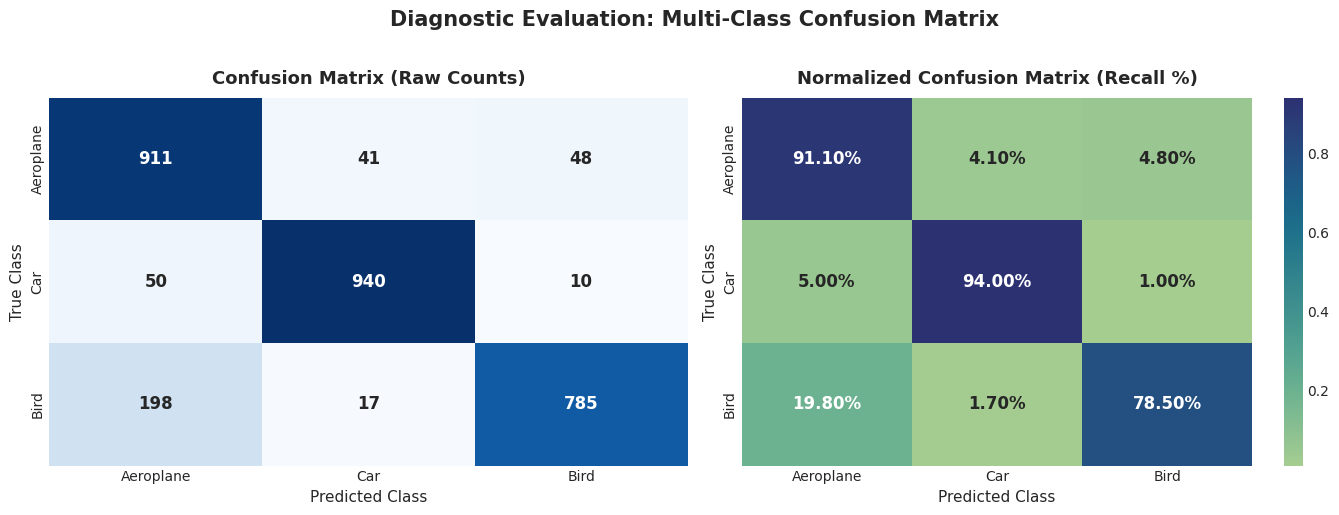

In [15]:
cm = confusion_matrix(y_true_classes, y_pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw count heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=[c.title() for c in class_names],
            yticklabels=[c.title() for c in class_names],
            annot_kws={'size': 12, 'weight': 'bold'})
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Predicted Class', fontsize=11)
ax1.set_ylabel('True Class', fontsize=11)

# Normalized percentage heatmap
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='crest', cbar=True, ax=ax2,
            xticklabels=[c.title() for c in class_names],
            yticklabels=[c.title() for c in class_names],
            annot_kws={'size': 12, 'weight': 'bold'})
ax2.set_title('Normalized Confusion Matrix (Recall %)', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Predicted Class', fontsize=11)
ax2.set_ylabel('True Class', fontsize=11)

plt.suptitle('Diagnostic Evaluation: Multi-Class Confusion Matrix', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id="63-per-class-classification-metrics-precision-recall-f1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.3 Per-Class Classification Metrics (Precision, Recall, F1)</span>

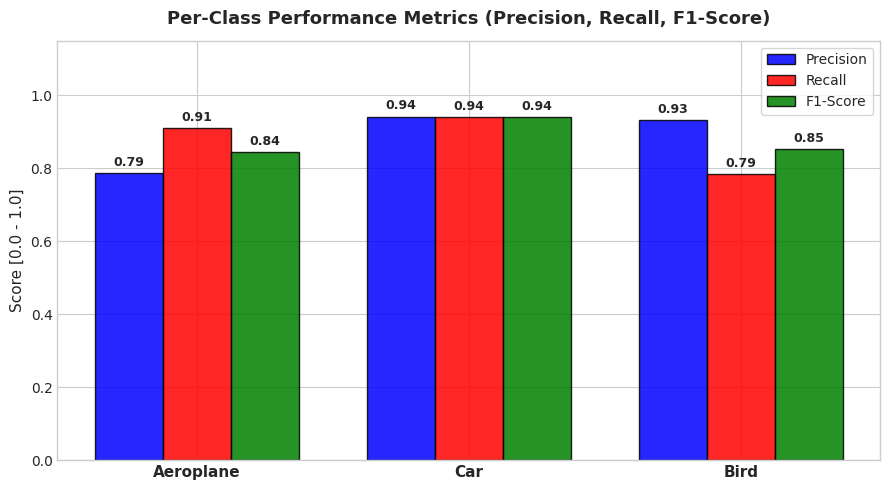


Classification Summary Report:
              precision    recall  f1-score   support

   Aeroplane       0.79      0.91      0.84      1000
         Car       0.94      0.94      0.94      1000
        Bird       0.93      0.79      0.85      1000

    accuracy                           0.88      3000
   macro avg       0.89      0.88      0.88      3000
weighted avg       0.89      0.88      0.88      3000



In [16]:
report_dict = classification_report(
    y_true_classes, y_pred_classes,
    target_names=[c.title() for c in class_names],
    output_dict=True
)

class_titles = [c.title() for c in class_names]
precisions = [report_dict[c]['precision'] for c in class_titles]
recalls = [report_dict[c]['recall'] for c in class_titles]
f1_scores = [report_dict[c]['f1-score'] for c in class_titles]

x = np.arange(len(class_titles))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width, precisions, width, label='Precision', color='blue', edgecolor='black', alpha=0.85)
rects2 = ax.bar(x, recalls, width, label='Recall', color='red', edgecolor='black', alpha=0.85)
rects3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='green', edgecolor='black', alpha=0.85)

# Value annotations
for rects in [rects1, rects2, rects3]:
    for bar in rects:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Per-Class Performance Metrics (Precision, Recall, F1-Score)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Score [0.0 - 1.0]', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(class_titles, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(frameon=True, fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Classification Summary Report:")
print("="*50)
print(classification_report(y_true_classes, y_pred_classes, target_names=[c.title() for c in class_names]))

<a id="64-prediction-confidence--softmax-probability-distributions"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.4 Prediction Confidence & Softmax Probability Distributions</span>

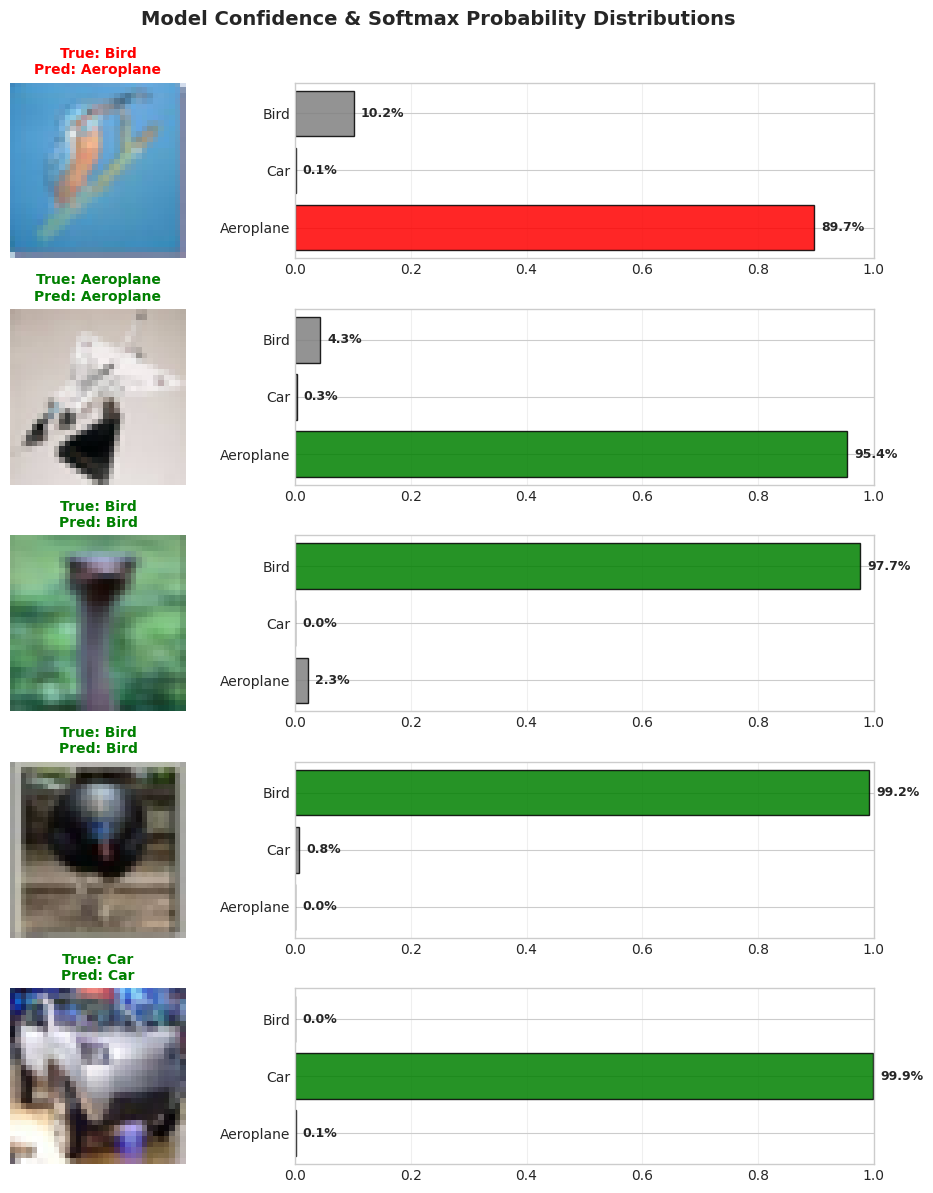

In [17]:
# Select 5 sample test images to visualize model prediction confidence
sample_indices = np.random.choice(len(x_test), size=5, replace=False)

fig, axes = plt.subplots(5, 2, figsize=(10, 12), gridspec_kw={'width_ratios': [1, 2]})

for row, idx in enumerate(sample_indices):
    img = x_test[idx]
    true_cls = class_names[y_true_classes[idx]]
    pred_probs = preds[idx]
    pred_cls = class_names[y_pred_classes[idx]]
    is_correct = (true_cls == pred_cls)

    # Left: Image display
    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    status_color = 'green' if is_correct else 'red'
    axes[row, 0].set_title(f"True: {true_cls.title()}\nPred: {pred_cls.title()}", color=status_color, fontweight='bold', fontsize=10)

    # Right: Horizontal softmax probability bar chart
    bar_colors = [
        'green' if i == np.argmax(pred_probs) and is_correct else
        ('red' if i == np.argmax(pred_probs) else 'gray')
        for i in range(3)
    ]
    bars = axes[row, 1].barh([c.title() for c in class_names], pred_probs, color=bar_colors, edgecolor='black', alpha=0.85)
    axes[row, 1].set_xlim(0, 1.0)
    for bar in bars:
        w = bar.get_width()
        axes[row, 1].annotate(f'{w*100:.1f}%', xy=(w, bar.get_y() + bar.get_height() / 2),
                              xytext=(5, 0), textcoords='offset points', ha='left', va='center', fontsize=9, fontweight='bold')
    axes[row, 1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Model Confidence & Softmax Probability Distributions', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

<a id="65-feature-map--layer-activation-visualization"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.5 Feature Map / Layer Activation Visualization</span>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


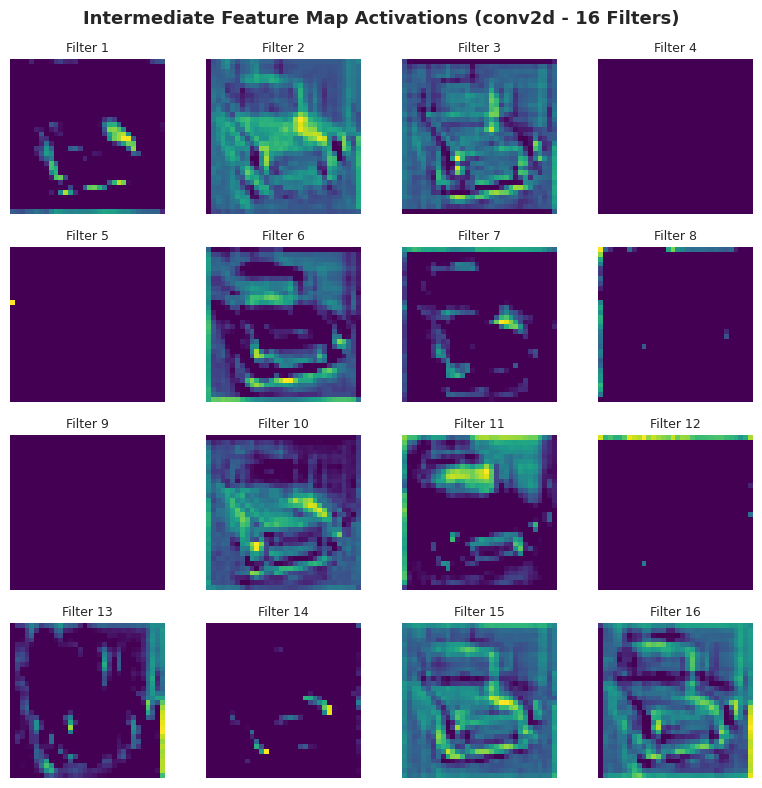

In [18]:
# Extract the first Conv2D layer to inspect intermediate feature activations
first_conv_layer = None
for layer in model.layers:
    if isinstance(layer, layers.Conv2D):
        first_conv_layer = layer
        break

if first_conv_layer:
    # Build activation model to inspect feature representations
    activation_model = models.Model(inputs=model.inputs, outputs=first_conv_layer.output)

    # Select first test sample
    sample_img = np.expand_dims(x_test[0], axis=0)
    activations = activation_model.predict(sample_img)

    # Plot first 16 feature maps in a 4x4 grid
    num_maps = min(16, activations.shape[-1])
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i in range(num_maps):
        ax = axes[i // 4, i % 4]
        ax.imshow(activations[0, :, :, i], cmap='viridis')
        ax.axis('off')
        ax.set_title(f"Filter {i+1}", fontsize=9)

    plt.suptitle(f'Intermediate Feature Map Activations ({first_conv_layer.name} - 16 Filters)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Conv2D layer not found for activation visualization.")

<a id="66-final-test-predictions-display"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.6 Final Test Predictions Display</span>

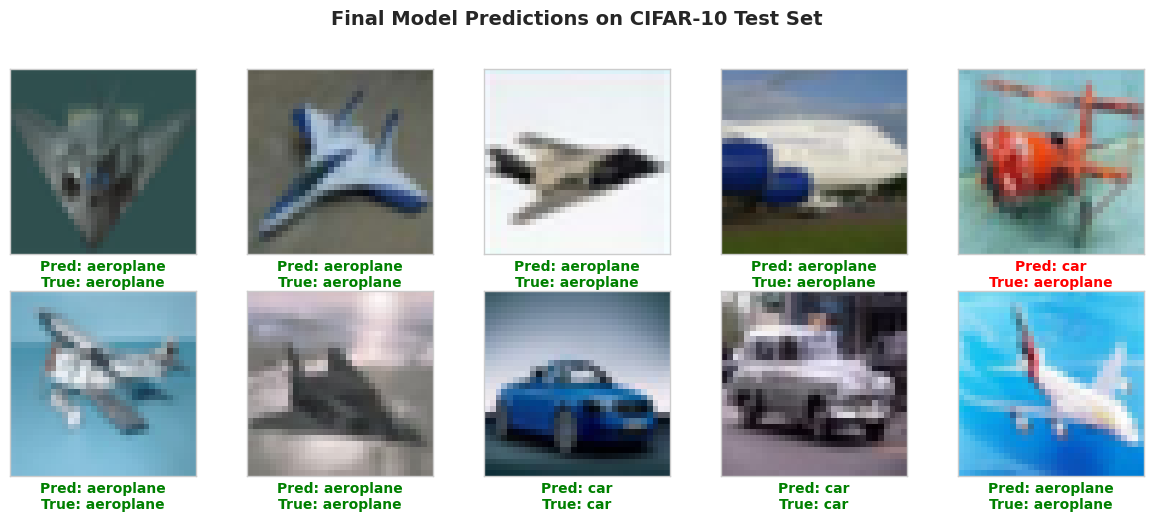

In [19]:
# Final visual verification on 10 random test samples
show_random_examples(x_test, y_test, preds, title="Final Model Predictions on CIFAR-10 Test Set")